# Physics Loss Investigation  - Teo Stages Approach.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


In [2]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------


import pandas as pd
import re
import numpy as np
from pvlib import location, pvsystem, modelchain
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

def get_station_metadata(station_num, df):
    """
    Retrieves and parses metadata for a specific station from the DataFrame.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe containing station metadata.
        
    Returns:
        dict: A clean dictionary with numerical values ready for simulation.
    """
    
    # 1. Format the station ID
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    if station_row.empty:
        raise ValueError(f"Station ID {station_id_str} not found in DataFrame.")
    
    # Get the single row as a Series
    row = station_row.iloc[0]

    # --- Helper 1: Parse "Key:Value" blocks (lines separated by \n) ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # --- Helper 2: Extract numeric values safely (e.g., "250 Wp" -> 250.0) ---
    def extract_num(val, default=0.0):
        if pd.isna(val): return default
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(val))
        return float(match.group()) if match else default

    # 3. Parse complex text columns into dictionaries
    module_items = parse_kv_string(row.get('Module', ''))
    inverter_items = parse_kv_string(row.get('Inverters', ''))
    layout_items = parse_kv_string(row.get('Layout', ''))

    # 4. Build the final clean dictionary
    # We use extract_num to ensure we pass numbers (floats/ints) to the model, not strings.
    metadata = {
        # --- Identity & Location ---
        'Station_ID': station_id_str,
        'Longitude': float(row['Longitude']),
        'Latitude': float(row['Latitude']),
        'Array_Tilt': row['Array_Tilt'], # Kept as string (e.g., "South 30") for parsing in main model
        
        # --- System Capacity & Dimensions ---
        'Capacity': float(row['Capacity']),          # Total Station Capacity (kW)
        'Panel_Size': float(row.get('Panel_Size', 1.62)), # Panel Area in m^2
        'Total_Panel_Number': int(row.get('Panel_Number', 0)),
        'PV_Technology': row['PV_Technology'],

        # --- Extracted Module Specs (Cleaned to Float) ---
        'Module_Pmax': extract_num(module_items.get('Pmax'), default=250),
        'Module_Vmpp': extract_num(module_items.get('Vmpp'), default=30),
        'Module_Impp': extract_num(module_items.get('Impp'), default=8),
        
        # --- Extracted Inverter Specs (Cleaned to Float) ---
        'Inverter_Rated_Power': extract_num(inverter_items.get('Rated power'), default=500),
        'Inverter_Max_DC_Voltage': extract_num(inverter_items.get('Max. DC voltage'), default=1000),
        
        # --- Extracted Layout Specs (Cleaned to Int) ---
        # Note: Layout strings can look like "modules per string:20"
        'Modules_per_String': int(extract_num(layout_items.get('modules per string'), default=20)),
        'Strings_per_Inverter': int(extract_num(layout_items.get('strings per inverter'), default=100)),
    }
    
    return metadata


def calculate_clearsky_indices(metadata, df):
    """
    Calculates both Irradiance (K_CS) and Power (K_PV) Clear Sky Indices.
    
    Args:
        metadata (dict): Parsed station metadata.
        df (pd.DataFrame): Time-series data with 'lmd_totalirrad' and 'power' columns.
                           'power' should be in MW (or kW, logic adapts).
                           'lmd_totalirrad' should be in W/m^2.
    
    Returns:
        pd.DataFrame: Original df with added columns 'GHI_clr', 'K_CS', 'P_CLR', 'K_PV'.
    """
    
    print(f"--- Processing {metadata.get('Station_ID', 'Unknown')} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    # The paper explicitly states timestamps are in Coordinated Universal Time (UTC).
    # Setting tz='UTC' ensures pvlib aligns Solar Noon correctly (approx 04:00 UTC for China).
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df['date_time'] = pd.to_datetime(df['date_time'])
        df.set_index('date_time', inplace=True)

    # ---------------------------------------------------------
    # 2. CALCULATE CLEAR SKY IRRADIANCE (GHI_clr)
    # ---------------------------------------------------------
    print("Calculating Clear Sky Irradiance (Ineichen model)...")
    
    # Calculate theoretical GHI (returns W/m^2)
    cs = site.get_clearsky(df.index, model='ineichen')
    df['GHI_clr'] = cs['ghi']

    # --- Index 1: Irradiance Clear Sky Index (K_CS) ---
    # Formula: K_CS = Measured GHI / Clear Sky GHI
    
    if 'lmd_totalirrad' in df.columns:
        # Standardize Measured Units: 
        # lmd_totalirrad is W/m^2.
        meas_ghi = df['lmd_totalirrad']
        

        # Calculate Index (Filter: Only when model expects sun > 10 W/m^2)
        # Naive filter to avoid night time noise
        df['K_CS_day'] = np.where(
            df['GHI_clr'] > 10, 
            meas_ghi / df['GHI_clr'], 
            0.0
        )
        df['K_CS_dayNight'] = meas_ghi / df['GHI_clr']

        df['K_CS'] = df['K_CS_day']
        
        # Clip outliers (cloud edge effects can cause > 1.0)
        df['K_CS'] = df['K_CS'].clip(lower=0.0, upper=1.25)
    else:
        print("Warning: 'lmd_totalirrad' column missing. K_CS not calculated.")

    # ---------------------------------------------------------
    # 3. SETUP PV SYSTEM MODEL (For P_CLR)
    # ---------------------------------------------------------
    # Extract Tilt safely from string 
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except Exception as e:
        print(f"Error extracting tilt: {e} .... Assuming 33 degrees")
        tilt = 33.0
    
    # Default Azimuth: 180 (South) for Northern Hemisphere
    azimuth = 180 

    # Define Module Parameters (Generic Poly-Si based on metadata)
    # Hard coded Module for specific station 07
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    # Module Parameters can be retreived from pvsystem.retrieve_sam by defining the module name and for now for simplicity we use hardcoded one.
    # module_params = {
    #     'pdc0': metadata['Module_Pmax'],   # STC Power (Watts)
    #     'gamma_pdc': -0.004,               # Temp coeff
    #     'b': 0.05, 'a': -3.56              # Sandia model defaults
    # }
    
    # Define Inverter Parameters (One Block)
    # Block Size = Modules per string * Strings per inverter * Module Power
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    

    # The same with Inverter infoirmation i used hardcoded info for station 07    
    # inv_params = pvsystem.retrieve_sam("cecinverter")

    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'], = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    inverter_parameters = ivt_para
    
    # Temperature Model (Open Rack)
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_parameters,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
        # modules_per_string=20, strings_per_inverter=100 # Must be retreived from metadata, but for now hardcoded
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN FOR POWER
    # ---------------------------------------------------------
    print("Running PV Power Simulation...")

    mc = ModelChain(system, site, transposition_model='perez',
                        solar_position_method='nrel_numpy',
                        aoi_model='physical', spectral_model='no_loss')

    # mc = modelchain.ModelChain(
    #     system, 
    #     site, 
    #     aoi_model='physical', 
    #     spectral_model='no_loss', 
    #     ac_model='pvwatts'
    # )

    # Run using the Clear Sky weather data
    mc.run_model(cs)

    # ---------------------------------------------------------
    # 5. SCALE & CALCULATE POWER INDEX (K_PV)
    # ---------------------------------------------------------
    # The simulation (mc.results.ac) is for ONE Block. Scale to full station.
    
    station_total_capacity_watts = metadata['Capacity'] * 1000  # kW -> Watts [cite: 109]
    scaling_factor = station_total_capacity_watts / block_dc_watts
    
    # Calculate Station Clear Sky Power (MW)
    # FillNa(0) handles night time; Divide by 1M to get MW
    p_clr_watts = mc.results.ac.fillna(0) * scaling_factor
    df['P_CLR'] = p_clr_watts / 1_000_000 

    # --- Index 2: Power Clear Sky Index (K_PV) ---
    # Formula: K_PV = Measured Power / Clear Sky Power
    
    if 'power' in df.columns:
        meas_power = df['power']
        
        # Check units: Paper says Power is MW[cite: 109].
        # Heuristic: If max > 500, it is likely kW, so divide by 1000.
        if meas_power.max() > 500:
            meas_power = meas_power / 1000.0
            
        # Calculate Index
        # Filter: Only calculate when model expects > 0.05 MW to avoid night noise
        df['K_PV'] = np.where(
            df['P_CLR'] > 1.0, 
            meas_power / df['P_CLR'], 
            0.0
        )
        
        # Clip for cleanliness (Values > 1.0 mean better than clear sky or model error)
        df['K_PV'] = df['K_PV'].clip(lower=0.0, upper=1.5)
    else:
        print("Warning: 'power' column missing. K_PV not calculated.")

    return df


def calculate_nwp_power(metadata, df):
    """
    Calculates the expected PV Power output (MW) based purely on NWP Weather Forecasts.
    This acts as a "Physics-Based Baseline" to compare against the AI model.
    
    Args:
        metadata (dict): Station metadata from get_station_metadata()
        df (pd.DataFrame): DataFrame containing 'nwp_' columns.
        
    Returns:
        pd.Series: The calculated power in MW, aligned with df.index.
    """
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"--- Calculating NWP Physical Power for {station_id} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    # Define Location (UTC to align with solar position)
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure DataFrame index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # ---------------------------------------------------------
    # 2. PREPARE WEATHER DATA (Map NWP -> PVLib Standard)
    # ---------------------------------------------------------
    # PVLib ModelChain expects columns: 'ghi', 'dni', 'dhi', 'temp_air', 'wind_speed', 'pressure'
    weather_nwp = pd.DataFrame(index=df.index)
    
    # Map available columns
    weather_nwp['ghi'] = df['nwp_globalirrad']
    weather_nwp['dni'] = df['nwp_directirrad']
    weather_nwp['temp_air'] = df['nwp_temperature']
    weather_nwp['wind_speed'] = df['nwp_windspeed']
    
    # Handle Pressure (Default to 101325 Pa if missing)
    if 'nwp_pressure' in df.columns:
        # Assumption: NWP pressure is often hPa, PVLib expects Pa. 
        # If your data is already Pa, remove the * 100.
        weather_nwp['pressure'] = df['nwp_pressure'] * 100 
    else:
        weather_nwp['pressure'] = 101325.0

    # CALCULATE MISSING DHI (Diffuse Horizontal Irradiance)
    # Physics Relation: GHI = DNI * cos(Zenith) + DHI
    # Therefore: DHI = GHI - (DNI * cos(Zenith))
    
    # Get Solar Position (Zenith) for every timestamp
    solpos = site.get_solarposition(weather_nwp.index)
    zenith_rad = np.radians(solpos['zenith'])
    
    # Calculate DHI
    weather_nwp['dhi'] = weather_nwp['ghi'] - (weather_nwp['dni'] * np.cos(zenith_rad))
    
    # Physics Check: Irradiance cannot be negative.
    # (Negative values happen when Sun is low and NWP GHI/DNI are slightly mismatched)
    weather_nwp['dhi'] = weather_nwp['dhi'].clip(lower=0.0)
    weather_nwp['dni'] = weather_nwp['dni'].clip(lower=0.0)
    weather_nwp['ghi'] = weather_nwp['ghi'].clip(lower=0.0)

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Hardware Specs)
    # ---------------------------------------------------------
    # Extract Tilt
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except:
        tilt = 33.0
        
    # Hardcoded/Standardized Equipment (Matching your previous Setup)
    # Module: Yingli YL250P-29b
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    
    # Inverter: Advanced Energy 500kW
    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    # Override generic params with specific constraints if needed
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'] = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    
    # Temp Model
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    # Create the System Object
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=180, # Facing South
        module_parameters=module_params,
        inverter_parameters=ivt_para,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
    )

    # ---------------------------------------------------------
    # 4. RUN PHYSICAL SIMULATION (ModelChain)
    # ---------------------------------------------------------
    print("Running ModelChain with NWP Weather...")
    
    mc = ModelChain(system, site, 
                    transposition_model='perez',
                    solar_position_method='nrel_numpy',
                    aoi_model='physical', 
                    spectral_model='no_loss')

    # Run the simulation using the PREPARED NWP weather
    mc.run_model(weather_nwp)
    
    # ---------------------------------------------------------
    # 5. SCALE TO FULL STATION CAPACITY
    # ---------------------------------------------------------
    # The simulation result (mc.results.ac) is for ONE "Inverter Block" defined above.
    # We must scale this up to match the total Station Capacity.
    
    # Calculate DC Watts of one defined block
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    
    # Get Total Station Capacity in Watts (Capacity is usually in kW in metadata)
    station_total_capacity_watts = metadata['Capacity'] * 1000
    
    # Scaling Factor
    if block_dc_watts > 0:
        scaling_factor = station_total_capacity_watts / block_dc_watts
    else:
        scaling_factor = 1.0 # Fallback to avoid div/0
        
    # Get AC Power, fill NaNs (night), scale, and convert to MW
    # result is in Watts -> divide by 1,000,000 for MW
    nwp_power_mw = (mc.results.ac.fillna(0) * scaling_factor) / 1_000_000
    
    # Final Clip (Power cannot be negative)
    nwp_power_mw = nwp_power_mw.clip(lower=0.0)
    
    print(f"Done. Mean Predicted Power: {nwp_power_mw.mean():.4f} MW")
    
    return nwp_power_mw


In [3]:
# ==========================================================
# Real Power PV generated power data.

# read the data for PVOD
abs_path = os.path.abspath("/home/muhammadhassan/App_v02/physics_informed_inves/PVODdatasets_v1")

station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)

In [4]:



# 3. Run Calculation
print(station07_metaData)
station07_df = calculate_clearsky_indices(station07_metaData, station07_data)

{'Station_ID': 'station07', 'Longitude': 113.64187, 'Latitude': 36.64403, 'Array_Tilt': 'South 31°', 'Capacity': 20000.0, 'Panel_Size': 1.6335, 'Total_Panel_Number': 80000, 'PV_Technology': 'Poly-Si', 'Module_Pmax': 250.0, 'Module_Vmpp': 29.8, 'Module_Impp': 8.39, 'Inverter_Rated_Power': 500.0, 'Inverter_Max_DC_Voltage': 1000.0, 'Modules_per_String': 20, 'Strings_per_Inverter': 100}
--- Processing station07 ---
Calculating Clear Sky Irradiance (Ineichen model)...
Running PV Power Simulation...


In [5]:
station07_df['NWP_Power_MW'] = calculate_nwp_power(station07_metaData, station07_df)

--- Calculating NWP Physical Power for station07 ---
Running ModelChain with NWP Weather...
Done. Mean Predicted Power: 3.2083 MW


In [6]:
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)

    # 3. Months
    data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

    # seasons 
    data['season_sin'] = np.sin(2 * np.pi * data.index.month / 4)
    data['season_cos'] = np.cos(2 * np.pi * data.index.month / 4)
    
    
    
    return data


station07_df = prepare_features(station07_df)




In [17]:
station07_df.head()

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,...,K_PV,NWP_Power_MW,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_sin,season_cos
date_time,,,,,,,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,...,0.0,0.0,-0.965926,-0.258819,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0


In [18]:
import os
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
from typing import List


warnings.filterwarnings('ignore')



class MultiStepDataset(Dataset):
    """
    prepare data set for the model. As X is the past F features, Y is the target and P is the prediction features represents the predictions of the corresponding time step after seq_len, 
    seq_len
    Returns:
        x_past   : [seq_len, F]
        y_future : [pred_len, 1]
        x_future : [pred_len, F]
    """
    def __init__(self, X, Y, P, seq_len=96, pred_len=96): # One day back and Forward.
        self.X = X  # numpy array [T, F]
        self.y = Y  # numpy array [T, 1] (K_PV)
        self.P = P  # numpy array [T, F]
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        # past window
        x_past = self.X[i : i + self.seq_len]  # [seq_len, F]

        # future horizon
        start_fut = i + self.seq_len
        end_fut   = start_fut + self.pred_len

        y_future = self.y[start_fut : end_fut]         # [pred_len, 1]
        x_future = self.P[start_fut : end_fut]         # [pred_len, F]

        return (
            torch.tensor(x_past,   dtype=torch.float32),
            torch.tensor(y_future, dtype=torch.float32),
            torch.tensor(x_future, dtype=torch.float32),
        )




def prepare_rolling_folds(
    df, input_cols, target_col, prediction_cols,
    n_splits=2, seq_len=96, pred_len=96, batch_size=32
):


    # types Validation 
    X_raw = df[input_cols].values.astype(np.float32)
    P_raw = df[prediction_cols].values.astype(np.float32)
    
    y_raw = df[target_col].values.astype(np.float32)

    # Expanding rolling window, usign retraining.
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    fold = 0
    for train_index, test_index in tscv.split(X_raw):
        fold += 1
        
        # Split Data
        X_train_fold = X_raw[train_index]
        P_train_fold = P_raw[train_index]
        y_train_fold = y_raw[train_index]

        X_test_fold = X_raw[test_index]
        P_test_fold = P_raw[test_index]
        y_test_fold = y_raw[test_index]

        # Prepend Lookback for Test Set
        # We need the last 'seq_len' points from train to predict the first point of test
        X_lookback = X_train_fold[-seq_len:]
        P_lookback = P_train_fold[-seq_len:]
        y_lookback = y_train_fold[-seq_len:]

        X_test_final = np.concatenate([X_lookback, X_test_fold], axis=0)
        P_test_final = np.concatenate([P_lookback, P_test_fold], axis=0)
        y_test_final = np.concatenate([y_lookback, y_test_fold], axis=0)

        # Create Datasets
        train_dataset = MultiStepDataset(
            X_train_fold, y_train_fold, P_train_fold, seq_len=seq_len, pred_len=pred_len
        )
        test_dataset = MultiStepDataset(
            X_test_final, y_test_final, P_test_final, seq_len=seq_len, pred_len=pred_len
        )

        # Create Loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        yield train_loader, test_loader




In [19]:
df = station07_df.copy(deep=True)

In [ ]:
import torch
import torch.nn as nn

# Official RevIN implementation https://github.com/ts-kim/RevIN 
"""
Reversible Instance Normalization
it removes the need for the model to learn different "rules" for Summer vs. Winter.

- In solar forecasting, a clear sunny day in winter has a much lower peak (amplitude) than a clear sunny day in summer due to the sun's angle. 
Standard models struggle because they see these as two different patterns
- RevIN normalizes each input window individually: 
    - It calculates the mean (μ) and standard deviation (σ) for just that specific window of time
    - It subtracts the mean and divides by the standard deviation.
To the model, a "Winter Sunny Day" and a "Summer Sunny Day" look almost identical (they both become a standardized curve). 
The model focuses on learning the shape (the curve of the sun, cloud interruptions) rather than the scale (magnitude).

RevIN handles Night records with zeroes elegantly because it is instance-based (local) rather than global.
- The paper describes "Affine Parameters" (γ,β) which are learnable weights in the normalization layer
    - Solar curves are not perfectly Gaussian (bell-shaped). The learnable parameters allow the model to slightly "shift" or "stretch" the normalized data to better fit the model's internal preferences.
    - 
"""

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, RevIN has learnable affine parameters
        """
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _init_params(self):
        # initialize RevIN params: (C,)
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x


class moving_avg(torch.nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = torch.nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x
        

class series_decomp(torch.nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean



from mamba_ssm import Mamba

import torch
import torch.nn as nn


class MMPISSM_Model_01(torch.nn.Module):
    def __init__(self, configs):
        super(MMPISSM_Model_01, self).__init__()
        self.configs = configs
        # Take the defined PowerMamba model as base model. 
        # self.model = PowerMamba(configs)

        # ------- NOTE: TO BE REMOVED AS IT IS PART OF THE POWERMAMBA MODEL. -----------
        # --- Dimensions ---
        self.num_past_feats = len(self.configs.PAST_INPUT_COLS)                     # Number of past features
        self.num_shadows   = len(self.configs.common_features)                      # Number of shadow features (NWP features)
        self.enc_in        = self.num_past_feats + self.num_shadows                 # Number of input features (past + shadow)

        # --- Pre-calculate Indices ---

        
        self.fut_indices = torch.tensor(
            [self.configs.FUTURE_INPUT_COLS.index(f) for f in self.configs.common_features], # Calculate the indices of the shadow features in the future input
            dtype=torch.long
        )
        self.past_target_indices = torch.tensor(
            [self.configs.PAST_INPUT_COLS.index(f) for f in self.configs.common_features],  # Calculate the indices of the shadow features in the past input
            dtype=torch.long
        )

        # Shadow columns in x_pred begin after the original past features
        self.shadow_start_idx = self.num_past_feats # index of the first shadow feature in x_pred = L

        
        # Projection: reduce the expanded length caused by appending external forecasts back down to the original sequence length.
        # This ensures that regardless of how long the prediction horizon (W) is, the input size entering the Mamba blocks remains a fixed length (L).
        # takes the concatenated seasonal/trend "long" sequence and squashes it back to the original context length L
        self.lin1 = nn.Linear(2 * (self.configs.seq_len + self.configs.pred_len), self.configs.seq_len)

        # indices of the target columns in the past input
        self.target_indices = [self.configs.PAST_INPUT_COLS.index(col) for col in self.configs.TARGET_COL]

        # Decomposition using Conv 1D kernel
        self.decompsition = series_decomp(self.configs.kernel_size)

        # Maintain the distributio drift using RevIN and its inverse.
        self.revin_layer = RevIN(self.enc_in)
        self.revin_layer_enc = RevIN(self.enc_in)


        # Projection of decomposition trend and the residual into the embedding space which has the same dimension as the input sequence to mainitan the input sequence length, as it doesnt matter how long is the input sequence.

        self.lin2 = nn.Linear(2 * self.configs.seq_len, self.configs.n_embed)
        self.lin3 = nn.Linear(4 * self.configs.n_embed, self.configs.pred_len)

        self.dropout1 = nn.Dropout(self.configs.dropout)
        self.dropout2 = nn.Dropout(self.configs.dropout)

        self.mamba1 = Mamba(
            d_model=self.configs.n_embed, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
        self.mamba2 = Mamba(
            d_model=self.configs.enc_in, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
    
    def forward(self, x, x_f):
        """
        Two stage approach prediction Module Temperature using unsupervised learning, by defining the loss to be the physical ODE of the thermal balancing.

        x:   [B, L, num_past_feats]
        x_f: [B, H, num_future_feats]

        return: [B, H, num_future_feats]
        """
        # define the new tensor to align the past and future features in a single tensor
        B = x.size(0)   #  # Number of feature in the past sequence input
        device = x.device           # same device as input
        L = self.configs.seq_len    # L
        H = self.configs.pred_len   # H

        # Ensure indices are on correct device
        if self.fut_indices.device != device:
            self.fut_indices = self.fut_indices.to(device)
            self.past_target_indices = self.past_target_indices.to(device)

        # ============================================================
        # 1. Input construction with OFFICIAL shift/windowing shadows
        # ============================================================
        total_len = L + H
        # Initialize the prediction tensor
        x_pred = torch.zeros(B, total_len, self.enc_in, device=device)

        # A) Fill original past data (history) into original feature slots
        x_pred[:, :L, :self.num_past_feats] = x

        # B) Extract horizon forecasts for the common/shadow features
        # shadow_forecasts: [B, H, S]
        shadow_forecasts = torch.index_select(x_f, 2, self.fut_indices)

        # C) Write forecasts into the FUTURE part of the corresponding original columns (proj_to behavior)
        # This is equivalent to: x_pred[:, -H:, proj_to] = external_prediction
        # Here, proj_to == past_target_indices[i] in your indexing.
        for i, past_idx in enumerate(self.past_target_indices):
            x_pred[:, L:, past_idx] = shadow_forecasts[:, :, i]

        # D) Shadow columns (future part) directly hold the forecast (optional but consistent with your design)
        x_pred[:, L:, self.shadow_start_idx:] = shadow_forecasts

        # E) Shadow columns (past part) are created by SHIFT/WINDOWING:
        # shadow_past[:, :L] = x_pred[:, -L:, proj_to]
        #
        # Since total_len = L+H, x_pred[:, -L:, past_idx] selects indices [H .. L+H-1]
        # which contains (L-H) late-history points + H forecast points.
        for i, past_idx in enumerate(self.past_target_indices):
            shadow_col = self.shadow_start_idx + i
            x_pred[:, :L, shadow_col] = x_pred[:, -L:, past_idx]

        # ============================================================
        # 2. Standard PowerMamba Processing 
        # ============================================================
        x = x_pred

        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)

        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x)

        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer_enc(x, 'denorm')

        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e = torch.cat([seasonal_init, trend_init], dim=1)
        x_e = torch.permute(x_e, (0, 2, 1))
        x_e = self.lin2(x_e)

        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        # permute to [B, L, E]  
        x_im = torch.permute(x_im, (0, 2, 1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0, 2, 1))

        x = torch.cat([x_im, x_m, x_m + x_im, x_e], dim=2)

        x = self.lin3(x)
        # permute to [B, H, E]
        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer(x, 'denorm')

        # Return only the target columns which must be appear in the past input
        x = x[:, :, self.target_indices]
        return x

        

        
        


def train_one_epoch(model, loader, optimizer, criterion, device, criterion_type='MSE'):
    model.train()
    total_loss = 0.0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        preds = model(x_past, x_future)

        if criterion_type == 'MSE':
            loss = criterion(preds, y_future)
        elif criterion_type == 'Physics':
            loss = criterion(preds, y_future)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold(model, loader, criterion, device=None, criterion_type='MSE'):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            
            preds = model(x_past, x_future)

            if criterion_type == 'MSE':
                loss = criterion(preds, y_future)
            # TODO: Physics based loss
            elif criterion_type == 'Physics': 
                loss = criterion(preds, y_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, T, 1]

    # Flatten for global metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae


import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

        
def run_rolling_cv(df, configs):
    results = []
    history = {}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
    

    fold_gen = prepare_rolling_folds(

        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = MMPISSM_Model_01(configs).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-3
        )
        
        criterion = nn.MSELoss().to(device)

        

        for epoch in range(configs.epochs):
            # linear decay of teacher forcing
            # tf_ratio = max(0.0, 0.5 - epoch / (configs.epochs * 0.8))

            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, device
            )
            val_loss, val_rmse, val_mae = evaluate_fold(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} |"
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold(model, test_loader, criterion)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history




In [21]:

class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 5        # L: Look-back window
        self.pred_len = 3     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = [ 'K_PV','nwp_globalirrad']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad']
        self.TARGET_COL = ['K_PV']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 32     
        self.d_state = 32      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 2
        self.batch_size = 2
        self.epochs = 5
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()

In [22]:
fold_gen = prepare_rolling_folds(

        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, test_loader = next(fold_gen)
        


In [13]:
x_past, y_future, x_future = next(iter(train_loader))
x_past.shape, y_future.shape, x_future.shape

(torch.Size([2, 5, 2]), torch.Size([2, 3, 1]), torch.Size([2, 3, 1]))

In [14]:
x_past

tensor([[[8.1395e-01, 6.2050e+02],
         [8.1353e-01, 6.4754e+02],
         [8.1653e-01, 6.8469e+02],
         [8.2779e-01, 7.0711e+02],
         [8.2943e-01, 7.3697e+02]],

        [[4.7061e-01, 2.1885e+02],
         [4.8862e-01, 2.7391e+02],
         [5.2015e-01, 3.0980e+02],
         [5.4885e-01, 3.6186e+02],
         [5.7234e-01, 3.9513e+02]]])

In [24]:


results01, history01 = run_rolling_cv(df, configs)




=== Training Fold 1/2 ===


TypeError: MMPISSM_Model_01.forward() takes 3 positional arguments but 4 were given

----

The physics loss function for the module-temperature PINN in the provided paper is based on the dynamic energy balance of the PV module. To evaluate this balance, the model calculates heat loss through **convection** and **radiation** from both the front and rear surfaces of the panel.

[text](https://gemini.google.com/share/c99a96faaf76)

### Stage 01

### Train Model with MMPISSM to predict the Moduel Temperature based on the heat balance ODE. 

#### The PINN Logic: Solving the Heat Balance
$$C_{module} \frac{dT_{module}}{dt} = Q_{in} - P_{out} - Q_{loss}$$
- $Q_{in}$ : Calculated as $\alpha I_{s} A$, where $\alpha$ is the module absorptivity, $I_{s}$ is the plane-of-array (slope) irradiance, and $A$ is the surface area.
- $P_{out}$: This term accounts for the energy converted into electricity rather than heat. It is modeled as a function of rated power ($W_{p}$), temperature coefficient ($\tau$), and irradiance ($I_{s}$).
- $Q_{loss}$: Heat loss to the environment (radiative and convective).
    - $Q_{conv}$: Heat transfer to the surrounding air from both the front and rear surfaces. This depends on the effective heat transfer coefficient ($h_{eff}$), which is highly sensitive to wind speed and direction
    - $Q_{rad}$: Heat emitted to the sky and ground. This follows the Stefan-Boltzmann law, using the module's emissivity ($\epsilon$) and the fourth power of the temperature difference between the module and its surroundings ($T_{mod}^4$-$T_{amb}^4$).


$$C_m \frac{dT_{mod}}{dt} = \alpha I_s - P_{out} - q_{conv} - q_{rad}$$

- $C_m$ / $C_{module}$: Heat capacity of the module.
- $\alpha I_s$: Solar energy absorbed (derived from GHI/DNI and tilt geometry).
- $P_{out}$: Efficiency-corrected power output (typically using the $W_{p}$ formula).
- $q_{conv}$: Convection loss (dependent on NWP wind speed).
- $q_{rad}$: Radiative loss to the sky (calculated using $T_{amb}$ and $T_{mod}$).


**To be able to build such physics informed model, we need the following parameters:**
1. Derived Geometric & Solar Features
    - Module Slope Irradiance ($I_{s}$): This is the most critical derived feature. It must be calculated from $DNI$ ($I_{b}$), $DHI$ ($I_{d}$), and GHI ($I_{g}$) using a transposition model that accounts for the panel's tilt ($\beta$) and the ground reflectivity ($\rho$).
    - Solar Geometry: The Sun’s zenith ($\theta_{z}$) and azimuth ($\theta_\gamma$) angles must be calculated using algorithms like PSA based on your site's geographic location and time.
2. Environmental Drivers
    - Wind Speed and Direction: These are essential to calculate the Reynolds number and determine the heat transfer coefficients for both the windward and leeward sides of the module.
    - Ambient Temperature ($T_{amb}$): Used directly in both the convection and radiation loss terms.
3. Physical Constants (System Parameters)
    - $C_m$: Heat capacity of the module.
    - $\alpha$: Module absorptivity.
    - $W_{p}$: Rated power of the module.
    - $\tau$: Temperature coefficient of the module.
    - $h_{eff}$: Effective heat transfer coefficient.
    - $\epsilon$: Emissivity of the module.


**Loss Fucntion**
$$\text{loss}_{\text{res}} = \frac{dT}{dt} - \left( \frac{\alpha I_s A - P_{out} - Q_{conv} - Q_{rad}}{C_{module}} \right)$$

- $I_{s}$: Module-Slope / Plane-of-Array Irradiance:This is the total solar energy hitting the tilted surface. It is the sum of beam, sky diffuse, and ground-reflected radiation.
    - $$I_s = I_{beam} + I_{sky\_diffuse} + I_{ground\_reflected}$$
    - $$I_s = DNI \cdot \cos(\theta_{AOI}) + DHI \cdot \left( \frac{1 + \cos \beta}{2} \right) + GHI \cdot \rho \cdot \left( \frac{1 - \cos \beta}{2} \right)$$
        - Beam Component: $DNI \cdot \cos(\theta_{AOI})$. we don't have DNI, So calculate it as: $DNI = \frac{GHI - DHI}{\cos \theta_z}$
        - $\theta_{AOI}$: Angle of Incidence is the angle between the sun and the panel's normal vector, calculated using solar zenith, solar azimuth, panel tilt ($\beta$=33), and panel azimuth (180).
        - Diffuse Component: $DHI \cdot \left( \frac{1 + \cos \beta}{2} \right)$. This accounts for the portion of the sky the tilted panel "sees."
        - Ground Component: $GHI \cdot \rho \cdot \left( \frac{1 - \cos \beta}{2} \right)$. Uses ground albedo (ρ), typically 0.2.

- $P_{out}$: This represents the energy that leaves the module as electricity. It is removed from the thermal balance because it is converted to power rather than heat. The Equation (from Paper Eq. 26):
    - $$P_{out} = W_p \cdot \frac{I_s}{1000} \cdot \left[ 1 + \tau (\hat{T}_{mod} - 25) \right]$$
        - $W_{p}$: Rated power (255 W for our modules).
        - $\tau$: Temperature coefficient of the module, −0.0042 or −0.42% C
        - $\hat{T}_{mod}$: The predicted module temperature (in degrees Celsius).
        - Note: If the sun is down ($I_{s}=0$), $P_{out}$ naturally becomes 0.


- $Q_{conv}$: Heat transfer to the surrounding air from both the front and rear surfaces. This depends on the effective heat transfer coefficient ($h_{eff}$), which is highly sensitive to wind speed and direction. The Equation (from Paper Eq. 27):
    - $$Q_{conv} = h_{eff} \cdot A \cdot (\hat{T}_{mod} - T_{amb})$$
    - $h_{eff}$ (Heat Transfer Coefficient): In the paper, this is calculated by combining free and forced convection: $$h_{eff} = (h_{free}^3 + h_{forced}^3)^{1/3}$$
    - Forced Convection ($h_{forced}$): For your turbulent windward side, use the simplified version: $$h_{forced} \approx 5.74 \cdot w^{0.8} \cdot L^{-0.2}$$
        - where w is NWP wind speed and L is module length, ≈ 1.64 m
        - $T_{amb}$: NWP ambient temperature.

- $Q_{rad}$: Heat emitted to the sky and ground. This follows the Stefan-Boltzmann law, using the module's emissivity ($\epsilon$) and the fourth power of the temperature difference between the module and its surroundings ($T_{mod}^4$-$T_{amb}^4$).
    - $$Q_{rad} = \sigma \cdot \epsilon \cdot A \cdot \left[ F_{sky} (\hat{T}_{mod,K}^4 - T_{sky,K}^4) + F_{grd} (\hat{T}_{mod,K}^4 - T_{amb,K}^4) \right]$$
        - Temperatures: Must be in Kelvin (T+273.15).
        - $\sigma$: Stefan-Boltzmann constant ($\sigma \approx 5.67 \times 10^{-8} \text{ W/m}^2\text{K}^4$)
        - $\epsilon$: Emissivity (typically 0.9).
        - $F_{sky}$: $F_{sky}= \frac{1+cos\beta}{2}$
        - $F_{grd}$: $F_{grd}= \frac{1-cos\beta}{2}$
        - $T_{sky}$: Can be simplified to $T_{amb}-6$ (Swinbank model) or just $T_{amb}$ for a Version 1 model.


The Physics Loss is the Mean Squared Error of this residual: $Loss_{physics}=mean(f^2)$
By minimizing this, the NN learns to output a temperature sequence where the rate of change ( $\frac{dT}{dt}$) is perfectly balanced by the energy entering (Sun) and leaving (Power + Wind + Radiation) the system.

        

        

    


In [64]:
import math
import torch
import torch.nn as nn

class PINNPhysicsLoss(nn.Module):
    def __init__(self, configs):
        super().__init__()
        self.alpha = 0.9
        self.sigma = 5.67e-8
        self.epsilon = 0.9
        self.C_mod = 11000
        self.Wp = 255
        self.tau = -0.0042
        self.A = 1.6236

        # IMPORTANT: set dt to match your data.
        #  data is 15 minutes, dt should be 900 (seconds), not 15.
        self.dt = 900

        beta_rad = math.radians(33.0)
        self.F_fs = 0.5 * (1.0 + math.cos(beta_rad))  # float
        self.F_fg = 0.5 * (1.0 - math.cos(beta_rad))  # float

        self.idx_ghi = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        self.idx_ta  = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        self.idx_ws  = configs.FUTURE_INPUT_COLS.index('nwp_windspeed')

    def residual(self, x_f, pred_temp):
        """
        Returns residual r = dT/dt_pred - dT/dt_theoretical
        r shape: [B, H-1]
        """
        dT_dt_pred = (pred_temp[:, 1:, :] - pred_temp[:, :-1, :]) / self.dt  # [B,H-1,1]

        Is = x_f[:, :-1, self.idx_ghi]          # [B,H-1]
        Ta = x_f[:, :-1, self.idx_ta]           # [B,H-1]
        ws = x_f[:, :-1, self.idx_ws]           # [B,H-1]
        T_current = pred_temp[:, :-1, 0]        # [B,H-1]

        Q_in = self.alpha * Is * self.A

        P_out = self.Wp * (1 + self.tau * (T_current - 25)) * (Is / 1000)

        h_eff = 5.7 + 3.8 * ws
        Q_conv = self.A * h_eff * (T_current - Ta)

        Tk = T_current + 273.15
        Tak = Ta + 273.15

        # As written, sky and ground are both Tak, so view factors sum to 1.
        Q_rad = self.A * self.sigma * self.epsilon * (
            (self.F_fs + self.F_fg) * (Tk**4 - Tak**4)
        )

        dT_dt_theoretical = (Q_in - P_out - Q_conv - Q_rad) / self.C_mod  # [B,H-1]

        r = dT_dt_pred.squeeze(-1) - dT_dt_theoretical  # [B,H-1]
        return r

    def forward(self, x_f, pred_temp):
        r = self.residual(x_f, pred_temp)
        return torch.mean(r**2)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()
        # 1. Model predicts Temperature.
        pred_temp = model(x_past, x_future, None)

        # 2. Physics Loss is the ONLY loss.
        # It forces pred_temp to satisfy the Heat Balance ODE.
        loss = criterion(x_future, pred_temp)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

import torch

def evaluate_physics(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_rmse = 0.0
    total_mae  = 0.0
    n_batches = 0

    with torch.no_grad():
        for x_past, _, x_future in loader:
            x_past = x_past.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, None)

            loss = criterion(x_future, preds)
            r = criterion.residual(x_future, preds)

            rmse = torch.sqrt(torch.mean(r**2))
            mae  = torch.mean(torch.abs(r))

            total_loss += loss.item()
            total_rmse += rmse.item()
            total_mae  += mae.item()
            n_batches += 1

    return total_loss / n_batches, total_rmse / n_batches, total_mae / n_batches



import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

        
def run_rolling_cv(df, configs):
    results = []
    history = {}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
    

    fold_gen = prepare_rolling_folds(

        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = Model(configs).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-3
        )
        
        criterion = PINNPhysicsLoss(configs).to(device)

        

        for epoch in range(configs.epochs):
            # linear decay of teacher forcing
            # tf_ratio = max(0.0, 0.5 - epoch / (configs.epochs * 0.8))

            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, device
            )

            val_loss, val_rmse, val_mae = evaluate_physics(
                model, test_loader, criterion, device
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} |"
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} "
                )

        final_loss, final_rmse, final_mae = evaluate_physics(model, test_loader, criterion, device)
        print(f"--> Fold {fold} Finished: ResidualRMSE={final_rmse:.4f}, ResidualMAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'loss': final_loss,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history






In [65]:
class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 672        # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad','nwp_temperature', 'nwp_windspeed' ,'K_PV', 'lmd_totalirrad', 'lmd_temperature',
       'hour_sin','hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature', 'nwp_windspeed']
        self.TARGET_COL = ['K_PV']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 64     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 2 
        self.batch_size = 128
        self.epochs = 25
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs_stage1 = MambaModelConfigs()

configs_stage1.TARGET_COL = ['nwp_temperature']
configs_stage1.c_out = 1 


=== Training Fold 1/2 ===
Epoch 005 |Train=0.0000 | Val=0.0001 
Epoch 010 |Train=0.0000 | Val=0.0001 
Epoch 015 |Train=0.0000 | Val=0.0001 
Epoch 020 |Train=0.0000 | Val=0.0001 
Epoch 025 |Train=0.0000 | Val=0.0001 
--> Fold 1 Finished: ResidualRMSE=0.0092, ResidualMAE=0.0067


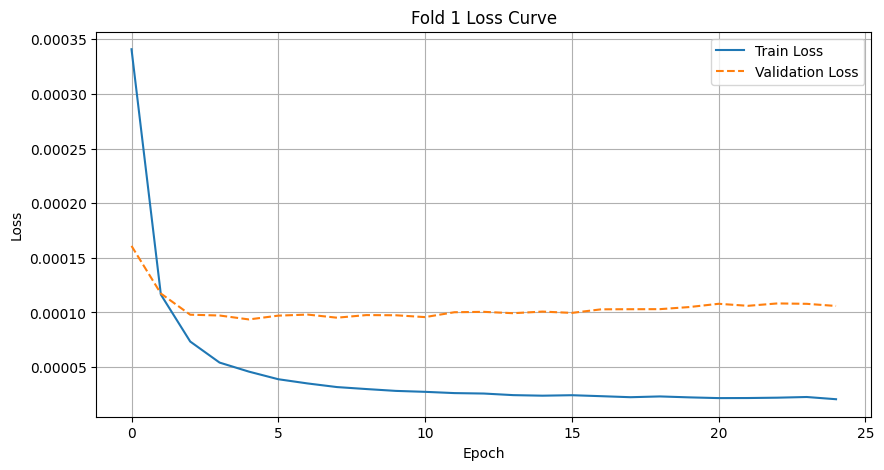


=== Training Fold 2/2 ===
Epoch 005 |Train=0.0000 | Val=0.0002 
Epoch 010 |Train=0.0000 | Val=0.0001 
Epoch 015 |Train=0.0000 | Val=0.0002 
Epoch 020 |Train=0.0000 | Val=0.0002 
Epoch 025 |Train=0.0000 | Val=0.0001 
--> Fold 2 Finished: ResidualRMSE=0.0112, ResidualMAE=0.0076


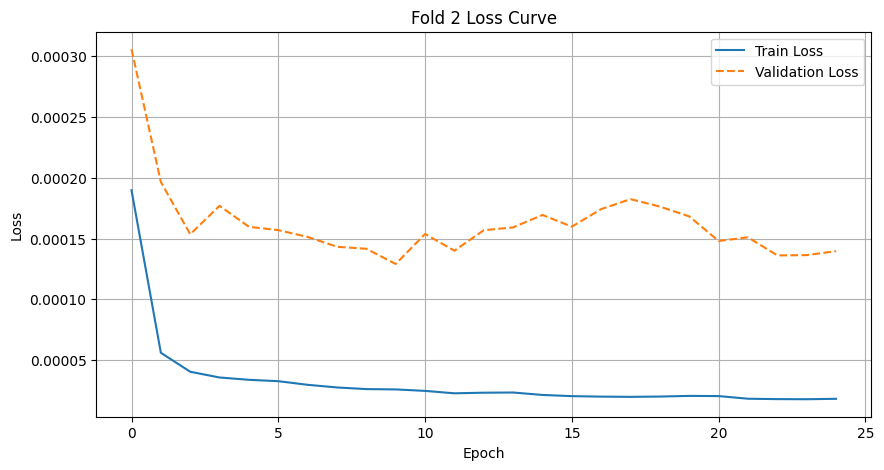


=== Final Cross-Validation Results ===
Average RMSE: 0.0102


In [66]:
results_physics_loss, history_physics_loss = run_rolling_cv(df, configs_stage1)

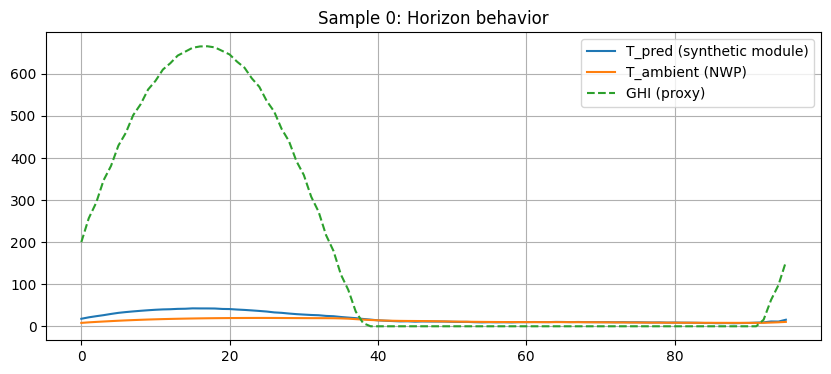

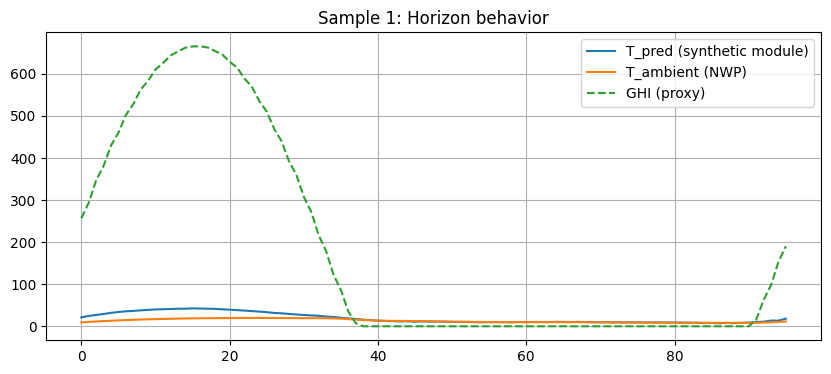

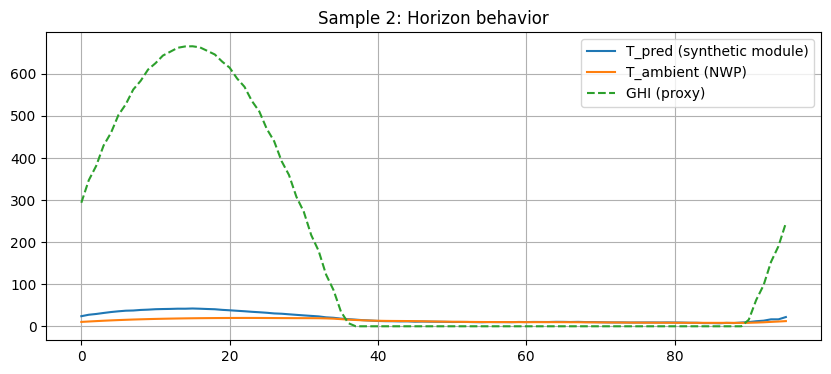

In [67]:
import matplotlib.pyplot as plt

def plot_sample_horizon(model, test_loader, configs, device=None, n_series=3):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    idx_ta  = configs.FUTURE_INPUT_COLS.index("nwp_temperature")
    idx_ghi = configs.FUTURE_INPUT_COLS.index("nwp_globalirrad")

    with torch.no_grad():
        x_past, _, x_future = next(iter(test_loader))
        x_past = x_past.to(device)
        x_future = x_future.to(device)

        pred = model(x_past, x_future, None).squeeze(-1).cpu().numpy()
        Ta   = x_future[..., idx_ta].cpu().numpy()
        GHI  = x_future[..., idx_ghi].cpu().numpy()

    for i in range(min(n_series, pred.shape[0])):
        plt.figure(figsize=(10,4))
        plt.plot(pred[i], label="T_pred (synthetic module)")
        plt.plot(Ta[i],   label="T_ambient (NWP)")
        plt.plot(GHI[i],  label="GHI (proxy)", linestyle="--")
        plt.title(f"Sample {i}: Horizon behavior")
        plt.grid(True)
        plt.legend()
        plt.show()

fold1 = results_physics_loss[0]
plot_sample_horizon(fold1["model"], fold1["test_loader"], configs_stage1)

In [68]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class WindowInferenceDataset(Dataset):
    """
    Creates rolling windows over df for Stage-1 inference, and returns
    the absolute indices of the horizon to write predictions into.
    """
    def __init__(self, df, past_cols, future_cols, seq_len, pred_len):
        self.past = df[past_cols].values.astype(np.float32)
        self.fut  = df[future_cols].values.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.N = len(df)

        self.max_start = self.N - (seq_len + pred_len)

    def __len__(self):
        return self.max_start + 1

    def __getitem__(self, i):
        L, H = self.seq_len, self.pred_len
        x_past = self.past[i : i+L]                 # [L, P]
        x_fut  = self.fut[i+L : i+L+H]              # [H, F]
        # indices in the original df that correspond to this horizon
        horizon_idx = np.arange(i+L, i+L+H, dtype=np.int64)  # [H]
        return torch.from_numpy(x_past), torch.from_numpy(x_fut), torch.from_numpy(horizon_idx)

In [69]:
def add_pinn_modtemp_column(df, stage1_model, configs_stage1, col_name="pinn_modtemp", batch_size=256):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    stage1_model = stage1_model.to(device)
    stage1_model.eval()

    ds = WindowInferenceDataset(
        df,
        past_cols=configs_stage1.PAST_INPUT_COLS,
        future_cols=configs_stage1.FUTURE_INPUT_COLS,
        seq_len=configs_stage1.seq_len,
        pred_len=configs_stage1.pred_len
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)

    N = len(df)
    pred_sum = np.zeros(N, dtype=np.float64)
    pred_cnt = np.zeros(N, dtype=np.float64)

    with torch.no_grad():
        for x_past, x_future, horizon_idx in dl:
            x_past = x_past.to(device)
            x_future = x_future.to(device)

            # Stage-1 predicts temperature horizon: [B, H, 1]
            pred = stage1_model(x_past, x_future, None).squeeze(-1)  # [B, H]

            pred_np = pred.detach().cpu().numpy()
            idx_np  = horizon_idx.numpy()

            # overlap averaging
            for b in range(pred_np.shape[0]):
                idx = idx_np[b]
                pred_sum[idx] += pred_np[b]
                pred_cnt[idx] += 1.0

    out = pred_sum / np.maximum(pred_cnt, 1.0)
    df[col_name] = out.astype(np.float32)

    # Fill edges that have no count (start of series) using nearest valid values
    df[col_name] = df[col_name].ffill().bfill()

    return df

In [ ]:
stage1_best_model = results_physics_loss[1]["model"]  # example
df2 = add_pinn_modtemp_column(df.copy(), stage1_best_model, configs_stage1, col_name="pinn_modtemp")